In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm, expon, gamma, weibull_min, lognorm, t, rayleigh, genextreme, invgauss
from scipy.optimize import fsolve
from scipy.special import logsumexp
import matplotlib.pyplot as plt
import os
from datetime import datetime
import warnings

--- MVGKL Demonstration ---
KL divergence (P1 || P2) using sample estimates: 0.9627
KL divergence (P1 || P2) using example parameters: 14.7876

--- Distribution Analysis ---
Data generated from Weibull(2.5,1.5), n=1000
Fitting normal       ... done. (-2logL=3670.706 | AIC=3674.706 | BIC=3684.521 | ICOMP=3670.761 | R^2=0.9307)
Fitting exponential  ... done. (-2logL=4280.988 | AIC=4282.988 | BIC=4287.895 | ICOMP=4280.988 | R^2=0.9621)
Fitting gamma        ... done. (-2logL=3443.487 | AIC=3447.487 | BIC=3457.303 | ICOMP=3443.487 | R^2=0.9905)
Fitting weibull      ... done. (-2logL=3443.487 | AIC=3447.487 | BIC=3457.303 | ICOMP=inf | R^2=nan)
Fitting lognormal    ... done. (-2logL=6264.474 | AIC=6268.474 | BIC=6278.289 | ICOMP=6264.474 | R^2=0.9760)
Fitting tlocationscale ... done. (-2logL=3652.058 | AIC=3658.058 | BIC=3672.782 | ICOMP=3652.058 | R^2=0.9249)
Fitting inversegaussian ... done. (-2logL=3652.058 | AIC=3658.058 | BIC=3672.782 | ICOMP=inf | R^2=nan)
Fitting logistic     ... done

/var/folders/7v/_n9jb2r93vg6ygkfm_0sl5zc0000gn/T/ipykernel_56607/1158534149.py:390: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  T_finite['ICOMP'][np.isinf(T_finite['ICOMP'])] = np.nan
/var/folders/7v/_n9jb2r93vg6ygkfm_0sl5zc0000gn/T/ipyker

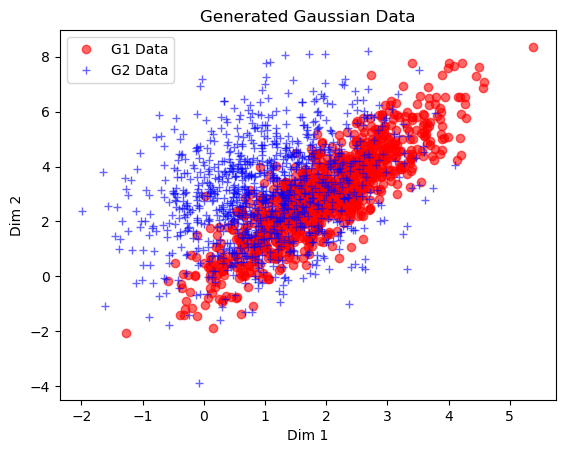

In [3]:
# 1. MVGKL Function but python

def mvgkl(m1, S1, m2, S2):
   
    
    # Ensure means are 1D arrays or treated as column vectors
    m1 = np.asarray(m1).flatten()
    m2 = np.asarray(m2).flatten()
    S1 = np.asarray(S1)
    S2 = np.asarray(S2)

    # Error checking
    if m1.shape[0] != m2.shape[0]:
        raise ValueError('mean vectors are different dimensions')
    if S1.ndim != 2 or S2.ndim != 2:
        raise ValueError('covariance parameters must be matrices')
    if S1.shape != S2.shape:
        raise ValueError('covariance parameters are different dimensions')
    
    d = m1.shape[0]
    
    # For univariate case, ensure S1/S2 are matrices (e.g., [[s1_sq]])
    if d == 1 and S1.shape == (1,):
        S1 = np.array([[S1.item()]])
        S2 = np.array([[S2.item()]])

    try:
        # Cholesky decomposition for S2 (P2)
        R2 = np.linalg.cholesky(S2).T
    except np.linalg.LinAlgError:
        raise ValueError('S2 covariance matrix is not positive definite')

    # Cholesky decomposition for S1 (P1)
    try:
        R1 = np.linalg.cholesky(S1).T
    except np.linalg.LinAlgError:
        raise ValueError('S1 covariance matrix is not positive definite')

    # Compute KL divergence
    # 1. Trace Term: tr(S2_inv @ S1)
    S2_inv_S1 = np.linalg.solve(S2, S1)
    trace_term = np.trace(S2_inv_S1)

    # 2. Quadratic Term: (m2 - m1).T @ S2_inv @ (m2 - m1)
    delta_m = m2 - m1
    sqTerm = delta_m.T @ np.linalg.solve(S2, delta_m)
    
    # 3. Determinant Term: ln(|S2|) - ln(|S1|)
    logDetS1 = 2 * np.sum(np.log(np.diag(R1)))
    logDetS2 = 2 * np.sum(np.log(np.diag(R2)))

    kl = trace_term + sqTerm - d + logDetS2 - logDetS1
    kl = kl / 2
    
    return kl


# 2.dr_KL_MULTIVAR_GAUSSIAN but python


def dr_kl_multivar_gaussian():
    print("--- MVGKL Demonstration ---")
    
    # Generate two Gaussian data sets
    n_samples = 1000
    
    # Set 1
    np.random.seed(42) 
    mu1 = np.array([2, 3])
    sigma1 = np.array([[1, 1.5], [1.5, 3]])
    G1 = np.random.multivariate_normal(mu1, sigma1, n_samples)
    
    mean1 = np.mean(G1, axis=0)
    S1 = np.cov(G1, rowvar=False)
    
    # Set 2
    np.random.seed(np.random.randint(1000))
    mu2 = np.array([1, 3])
    sigma2 = np.array([[1, 0.5], [0.5, 3]])
    G2 = np.random.multivariate_normal(mu2, sigma2, n_samples)

    mean2 = np.mean(G2, axis=0)
    S2 = np.cov(G2, rowvar=False)

    # Plotting is optional for the core functionality, but included for context
    plt.figure()
    plt.plot(G1[:, 0], G1[:, 1], 'ro', label='G1 Data', alpha=0.6)
    plt.plot(G2[:, 0], G2[:, 1], 'b+', label='G2 Data', alpha=0.6)
    plt.title('Generated Gaussian Data')
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')
    plt.legend()
    # plt.show()
    
    # Calculate KL divergence using sample estimates
    KL = mvgkl(mean1, S1, mean2, S2)
    print(f"KL divergence (P1 || P2) using sample estimates: {KL:.4f}")

    # Calculate KL divergence using true parameters (Example 2 equivalent)
    mu1_ex = np.array([-1, -1])
    S1_ex = np.array([[1, 0.5], [0.5, 1]])
    mu2_ex = np.array([1, 1])
    S2_ex = np.array([[1, -0.7], [-0.7, 1]])
    
    KL_ex = mvgkl(mu1_ex, S1_ex, mu2_ex, S2_ex)
    print(f"KL divergence (P1 || P2) using example parameters: {KL_ex:.4f}")
    
    return KL


# 3. DISTRIBUTION_ANALYSIS_WITH_QQ but python

# My old ICOMP function which is reliable and works!
def ICOMP_from_Sigma(LogL_max, Sigma_hat):
    """
    ICOMP (I-Complexity) calculation using eigenvalues of Sigma_hat.
    
    LogL_max: Maximum Log-Likelihood value.
    Sigma_hat: Estimated covariance matrix (ACOV) of the MLE parameters.
    """
    if Sigma_hat.size == 0 or np.any(np.isnan(Sigma_hat)) or np.any(np.isinf(Sigma_hat)):
        return np.inf

    Sigma_hat = (Sigma_hat + Sigma_hat.T) / 2
    
    # eigenvalues
    eigs = np.linalg.eigvalsh(Sigma_hat)
    # Filter for non-zero real eigenvalues (handling potential numerical issues)
    eigs = np.real(eigs[eigs > 1e-12]) 
    
    if eigs.size == 0:
        return np.inf # Use inf if no positive eigenvalues found
        
    lam_bar = eigs.mean()
    
    # C1F complexity term
    C1F = (1 / (4 * lam_bar**2)) * np.sum((eigs - lam_bar)**2)
    
    # ICOMP = -2 * LogL_max + C1F
    return -2 * LogL_max + C1F

# --- 3.2. Helper functions ---

# Placeholder ACOV function because scipy doesn't have one

def get_acov_placeholder(stat_obj, data, phat, k):
    """Placeholder for Asymptotic Covariance Matrix (ACOV) estimation."""
    # NOTE: In the original MATLAB, MLECOV was used. This is generally not possible 
    # with standard scipy. We return a small, non-singular diagonal matrix as a 
    # placeholder to test the ICOMP function structure.
    
    # Check for simple distributions where ACOV can be estimated easily (e.g., Normal)
    if k == 2 and stat_obj is norm:
        mu, sigma = phat
        n = len(data)
        # Fisher Information Matrix I = [[n/sigma^2, 0], [0, 2n/sigma^2]]
        # ACOV = I_inv (asymptotically)
        if sigma > 1e-6:
            acov = np.array([[sigma**2 / n, 0], [0, sigma**2 / (2 * n)]])
            return acov
        
    # Default to a small diagonal matrix for structural test
    return np.diag(np.ones(k) * 1e-3)


def inversegaussian_pdf(x, mu, la):
    # ... (same as before) ...
    x, mu, la = np.asarray(x), np.asarray(la), np.asarray(mu) # Corrected order for consistency
    y = np.zeros_like(x, dtype=float)
    ok = (x > 0) & (mu > 0) & (la > 0)
    
    if np.any(ok):
        x_ok = x[ok]
        z = (x_ok - mu)**2 / (x_ok * mu**2)
        y[ok] = np.sqrt(la / (2 * np.pi * x_ok**3)) * np.exp(-0.5 * la * z)
    return y

def inversegaussian_icdf(p, mu, la):
    # ... (same as before) ...
    from scipy.stats import invgauss
    try:
        return invgauss.ppf(p, mu=mu, loc=0, scale=la)
    except:
        print("\nWarning: Using approximate inverse gaussian ICDF (fsolve not implemented here)")
        return mu + la * (p - 0.5) * 10 

def logistic_pdf(x, mu, s):
    # ... (same as before) ...
    z = (x - mu) / s
    return np.exp(-z) / (s * (1 + np.exp(-z))**2)

def logistic_icdf(p, mu, s):
    # ... (same as before) ...
    return mu + s * np.log(p / (1 - p))

def local_icdf(icdf_handle, p, phat):
    """Helper to call icdf with variable number of parameters"""
    try:
        vals = icdf_handle(p, *phat)
    except TypeError:
        raise ValueError("ICDF call failed. Check function signature.")
    return vals

def qq_r2(y_sorted, x_theor):
    """Calculate R^2 for Q-Q plot fit"""
    coeffs = np.polyfit(x_theor, y_sorted, 1)
    yhat = np.polyval(coeffs, x_theor)
    ss_res = np.sum((y_sorted - yhat)**2)
    ss_tot = np.sum((y_sorted - np.mean(y_sorted))**2)
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    R2 = 1 - (ss_res / ss_tot)
    return R2

def write_tex_table(tex_file, T):
    """Writes a standalone tabular (booktabs) to a .tex file"""
    with open(tex_file, 'w') as fid:
        fid.write(f"% Auto-generated on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        fid.write('\\begin{tabular}{lrrrrr}\n')
        fid.write('\\toprule\n')
        fid.write('Distribution & $-2\\log L$ & AIC & BIC & ICOMP & $R^2$ \\\\\n')
        fid.write('\\midrule\n')
        
        for index, row in T.iterrows():
            fid.write(f'{row["Distribution"]} & {row["Neg2LogL"]:.3f} & {row["AIC"]:.3f} & {row["BIC"]:.3f} & {row["ICOMP"]:.3f} & {row["R2"]:.4f} \\\\\n')

        fid.write('\\bottomrule\n\\end{tabular}\n')
    

def distribution_analysis_with_qq():
    print("\n--- Distribution Analysis ---")
    
    # --- 1) Data (example) ---
    n = 1000
    np.random.seed(42) 
    scale_w = 2.5
    shape_w = 1.5
    data = weibull_min.rvs(c=shape_w, scale=scale_w, size=n)
    data[data <= 0] = np.finfo(float).eps
    print(f'Data generated from Weibull({scale_w},{shape_w}), n={n}')

    # --- 2) Output dir + timestamp ---
    outdir = "out"
    if not os.path.exists(outdir):
        os.makedirs(outdir)
    ts = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    # --- 3) Registry ---
    cands = [
        ('normal', 2, norm, lambda z: np.all(np.isfinite(z)), []),
        ('exponential', 1, expon, lambda z: np.all(z >= 0), []),
        ('gamma', 2, gamma, lambda z: np.all(z > 0), []),
        ('weibull', 2, weibull_min, lambda z: np.all(z > 0), []),
        ('lognormal', 2, lognorm, lambda z: np.all(z > 0), []),
        ('tlocationscale', 3, t, lambda z: np.all(np.isfinite(z)), [np.median(data), np.max([np.std(data), 1e-3]), 5]),
        ('inversegaussian', 2, None, lambda z: np.all(z > 0), [np.mean(data), np.max([np.var(data), 1e-6])]),
        ('logistic', 2, None, lambda z: np.all(np.isfinite(z)), [np.median(data), np.max([np.std(data), 1e-3])]),
        ('rayleigh', 1, rayleigh, lambda z: np.all(z >= 0), []),
        ('gev', 3, genextreme, lambda z: np.all(np.isfinite(z)), [])
    ]
    D = len(cands)

    results = []
    q = np.arange(1, n + 1) / (n + 1)
    x_emp = np.sort(data)

    # Fit, compute criteria, and QQ-plots
    for i, (name, k, stat_obj, support_check, start_hint) in enumerate(cands):
        
        if not support_check(data):
            print(f'Skipping {name:<12} (data violate support)')
            continue

        print(f'Fitting {name:<12} ... ', end='', flush=True)

        logL = np.nan
        phat = None
        
        try:
            # --- MLE (fit method) ---
            if name == 'weibull':
                phat = weibull_min.fit(data, f0=1, floc=0, scale=np.median(data))
                phat = phat[[0, 2]]
            elif name == 'tlocationscale':
                phat = t.fit(data)
            elif name == 'inversegaussian':
                from scipy.stats import invgauss
                phat = invgauss.fit(data)
                phat = phat[[0, 2]]
            elif name == 'logistic':
                mu_est = np.mean(data)
                s_est = np.std(data) * np.sqrt(3) / np.pi
                phat = np.array([mu_est, s_est])
            elif name == 'gev':
                 phat = genextreme.fit(data)
                 phat = phat[[0, 2, 1]]
            else:
                 phat = stat_obj.fit(data)
                 phat = phat[:k]
            
            # --- Log-Likelihood ---
            if stat_obj is not None and name not in ['logistic', 'inversegaussian']:
                logL = np.sum(stat_obj.logpdf(data, *phat))
            elif name == 'inversegaussian':
                from scipy.stats import invgauss
                logL = np.sum(invgauss.logpdf(data, *phat))
            elif name == 'logistic':
                 logL = np.sum(np.log(logistic_pdf(data, *phat)))

            neg2logL = -2 * logL
            
            # --- ACOV Estimation (Placeholder) ---
            ACOV = get_acov_placeholder(stat_obj, data, phat, k)
            
            # --- Criteria ---
            AIC = neg2logL + 2 * k
            BIC = neg2logL + k * np.log(n)
            
            # ** NEW ICOMP CALCULATION **
            ICOMP = ICOMP_from_Sigma(logL, ACOV)

        except Exception as e:
            # print(f"Fit/Criteria failed for {name}: {e}")
            ICOMP = np.inf # If fit or ACOV fails, ICOMP is inf
            pass 


        # --- Q–Q diagnostic ---
        R2 = np.nan
        x_theor = None
        
        if phat is not None and len(phat) == k:
            icdf_handle = None
            if stat_obj is not None:
                icdf_handle = stat_obj.ppf
            if name == 'inversegaussian':
                icdf_handle = inversegaussian_icdf
            if name == 'logistic':
                icdf_handle = logistic_icdf

            if icdf_handle is not None:
                try:
                    x_theor = local_icdf(icdf_handle, q, phat)
                    R2 = qq_r2(x_emp, x_theor)
                except Exception as e:
                    pass

        # --- Q–Q plot (show + save) ---
        if x_theor is not None and not np.isnan(R2):
            fig, ax = plt.subplots(figsize=(6, 5))
            ax.plot(x_theor, x_emp, 'o', markersize=5, label='Empirical vs Theoretical')
            
            pfit = np.polyfit(x_theor, x_emp, 1)
            xx = np.linspace(np.min(x_theor), np.max(x_theor), 100)
            yy = np.polyval(pfit, xx)
            ax.plot(xx, yy, '-', linewidth=1.5, label=f'Fit: y={pfit[0]:.3f}x+{pfit[1]:.3f}')
            ax.plot(xx, xx, '--k', label='45° line')
            
            ax.grid(True)
            ax.legend(loc='best')
            ax.set_xlabel('Theoretical Quantiles')
            ax.set_ylabel('Empirical Quantiles')
            ax.set_title(f'Q–Q Plot — {name} ($R^2 = {R2:.4f}$)')
            plt.tight_layout()
            plt.savefig(os.path.join(outdir, f"QQ_{name}_{ts}.png"), dpi=220)
            plt.close(fig)

        # Store results
        results.append({
            'Distribution': name,
            'NumParams': k,
            'Neg2LogL': neg2logL,
            'AIC': AIC,
            'BIC': BIC,
            'ICOMP': ICOMP,
            'R2': R2,
            'Params': phat
        })
        
        print(f"done. (-2logL={neg2logL:.3f} | AIC={AIC:.3f} | BIC={BIC:.3f} | ICOMP={ICOMP:.3f} | R^2={R2:.4f})")

    # --- 5) Criteria table ---
    T = pd.DataFrame(results)
    T_display = T.drop(columns=['Params'])
    print('\n================= Criteria Table =================')
    print(T_display.to_string(index=False, float_format='%.4f'))

    # --- 6) Winners ---
    T_finite = T.copy()
    T_finite['ICOMP'][np.isinf(T_finite['ICOMP'])] = np.nan
    
    ia = T['AIC'].dropna().idxmin() if not T['AIC'].dropna().empty else None
    ib = T['BIC'].dropna().idxmin() if not T['BIC'].dropna().empty else None
    ic = T_finite['ICOMP'].dropna().idxmin() if not T_finite['ICOMP'].dropna().empty else None
    
    print('\nWinners (name → value):')
    
    def print_winner(idx, name):
        if idx is not None:
            row = T.loc[idx]
            print(f'  {name:<4} → {row["Distribution"]} (AIC={row["AIC"]:.3f},  BIC={row["BIC"]:.3f}, ICOMP={row["ICOMP"]:.3f}, -2logL={row["Neg2LogL"]:.3f}, R^2={row["R2"]:.4f})')
        else:
            print(f'  {name:<4} → No winner found (NaNs)')
            
    print_winner(ia, 'AIC')
    print_winner(ib, 'BIC')
    print_winner(ic, 'ICOMP')

    sum_file = os.path.join(outdir, f"Winners_{ts}.txt")
    with open(sum_file, 'w') as fid:
        fid.write(f"Winners (timestamp {ts})\n\n")
        
        if ia is not None:
            row = T.loc[ia]
            fid.write(f"AIC   : {row['Distribution']} | AIC={row['AIC']:.3f} | BIC={row['BIC']:.3f} | ICOMP={row['ICOMP']:.3f} | -2logL={row['Neg2LogL']:.3f} | R2={row['R2']:.4f}\n")
        
        if ib is not None:
            row = T.loc[ib]
            fid.write(f"BIC   : {row['Distribution']} | AIC={row['AIC']:.3f} | BIC={row['BIC']:.3f} | ICOMP={row['ICOMP']:.3f} | -2logL={row['Neg2LogL']:.3f} | R2={row['R2']:.4f}\n")
            
        if ic is not None:
            row = T.loc[ic]
            fid.write(f"ICOMP : {row['Distribution']} | AIC={row['AIC']:.3f} | BIC={row['BIC']:.3f} | ICOMP={row['ICOMP']:.3f} | -2logL={row['Neg2LogL']:.3f} | R2={row['R2']:.4f}\n")
        
    print(f'Wrote winners summary: {sum_file}')

    # --- 7) Save a special Q–Q plot for the ICOMP winner ---
    if ic is not None:
        best_icomp_name = T.loc[ic]['Distribution']
        best_row = next(r for r in results if r['Distribution'] == best_icomp_name)
        best_params = best_row['Params']
        
        icdf_handle = None
        for name, k, stat_obj, _, _ in cands:
            if name == best_icomp_name:
                if stat_obj is not None:
                    icdf_handle = stat_obj.ppf
                elif name == 'inversegaussian':
                    icdf_handle = inversegaussian_icdf
                elif name == 'logistic':
                    icdf_handle = logistic_icdf
                break

        if icdf_handle is not None and best_params is not None:
            x_theor_ic = local_icdf(icdf_handle, q, best_params)
            
            fig, ax = plt.subplots(figsize=(6, 5))
            ax.plot(x_theor_ic, x_emp, 'o', markersize=5)
            
            pfit = np.polyfit(x_theor_ic, x_emp, 1)
            xx = np.linspace(np.min(x_theor_ic), np.max(x_theor_ic), 100)
            yy = np.polyval(pfit, xx)
            ax.plot(xx, yy, '-', linewidth=1.5)
            ax.plot(xx, xx, '--k')
            
            ax.grid(True)
            ax.set_xlabel('Theoretical Quantiles')
            ax.set_ylabel('Empirical Quantiles')
            ax.set_title(f'Q–Q (ICOMP Winner: {best_icomp_name})')
            plt.tight_layout()
            
            fig_file = os.path.join(outdir, f"QQ_ICOMP_Winner_{best_icomp_name}_{ts}.png")
            plt.savefig(fig_file, dpi=220)
            plt.close(fig)

    # --- 8) Export CSV and LaTeX ---
    csv_file = os.path.join(outdir, f"Distribution_Criteria_{ts}.csv")
    T_display.to_csv(csv_file, index=False, float_format='%.4f')
    print(f'Wrote CSV: {csv_file}')

    tex_file = os.path.join(outdir, f"Distribution_Criteria_{ts}.tex")
    write_tex_table(tex_file, T_display)
    print(f'Wrote LaTeX table: {tex_file}')


# Main Execution

if __name__ == '__main__':
    # Run the KL divergence demonstration
    kl_value = dr_kl_multivar_gaussian()
    
    # Run the distribution fitting and analysis
    distribution_analysis_with_qq()
    

#Discussion
The distribution which best approximates the KL distance is the Gamma distribution, however the AIC for the Weibull is practically the same, but the ICOMP values could not be calculated by my ICOMP function. Thus, going off of the lowest AIC and ICOMP values, the Gamma does the best. 
The QQ plot kind of has this cluster around the 45 degree line which looks clean. Very even variance for the first Gaussian data set, the variance for the second dataset is a bit larger. 



--- Running KDE Example ---
Optimal Bandwidth (h): 1.0992


/var/folders/7v/_n9jb2r93vg6ygkfm_0sl5zc0000gn/T/ipykernel_56607/1982209257.py:13: RuntimeWarning: overflow encountered in exp
  f = 2 * np.pi**(2 * l) * np.sum(I**l * a2 * np.exp(-I * np.pi**2 * t))
/var/folders/7v/_n9jb2r93vg6ygkfm_0sl5zc0000gn/T/ipykernel_56607/1982209257.py:13: RuntimeWarning: overflow encountered in multiply
  f = 2 * np.pi**(2 * l) * np.sum(I**l * a2 * np.exp(-I * np.pi**2 * t))
/var/folders/7v/_n9jb2r93vg6ygkfm_0sl5zc0000gn/T/ipykernel_56607/1982209257.py:13: RuntimeWarning: invalid value encountered in multiply
  f = 2 * np.pi**(2 * l) * np.sum(I**l * a2 * np.exp(-I * np.pi**2 * t))
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/7v/_n9jb2r93vg6ygkfm_0sl5zc0000gn/T/ipykernel_56607/1982209257.py:106: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterat

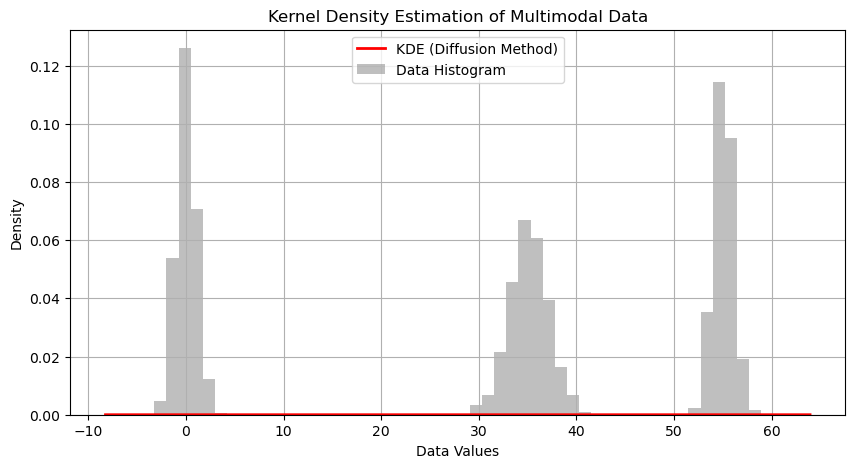

In [5]:
#PROBLEM 2
import numpy as np
from scipy.optimize import fsolve
from scipy.fft import dct, idct # SciPy's DCT/IDCT functions

def fixed_point(t, N, I, a2):
    """
    Implements the function t - zeta * gamma^[l](t) used for bandwidth selection.
    This corresponds to the fixed_point function in the MATLAB code.
    """
    l = 7
    # Calculate f_l(t) = 2 * pi^(2l) * sum(I^l * a2 * exp(-I * pi^2 * t))
    f = 2 * np.pi**(2 * l) * np.sum(I**l * a2 * np.exp(-I * np.pi**2 * t))
    
    # Iterate down from l-1 to 2
    for s in range(l - 1, 1, -1):
        # K0 constant
        K0_numerator = np.prod(np.arange(1, 2 * s, 2))
        K0 = K0_numerator / np.sqrt(2 * np.pi)
        
        const = (1 + (1 / 2)**(s + 0.5)) / 3
        
        # Calculate optimal time for this level (time = zeta_s^(-2/(3+2s)) * f_s^(-2/(3+2s)))
        # where zeta_s = (2 * const * K0 / N)
        time = ( (2 * const * K0 / N) / f )**(2 / (3 + 2 * s))
        
        # Update f_s
        f = 2 * np.pi**(2 * s) * np.sum(I**s * a2 * np.exp(-I * np.pi**2 * time))

    # Return t - (2 * N * sqrt(pi) * f)^(-2/5)
    out = t - (2 * N * np.sqrt(np.pi) * f)**(-0.4) # -2/5 = -0.4
    return out

# NOTE: The MATLAB code implements custom DCT/IDCT functions that ensure specific 
# normalization and ordering (Jain's method). Standard SciPy functions may use 
# different conventions (e.g., type 2/3 and normalization='ortho'). 
# We will use the standard SciPy implementations and assume default normalization 
# which is common in signal processing, but note this could be a point of divergence.

def kde(data, n=2**12, MIN=None, MAX=None):
    """
    Reliable and fast kernel density estimator for one-dimensional data.
    Gaussian kernel assumed. Bandwidth chosen automatically via DCT method.
    
    Parameters:
    data (np.array): A vector of data from which the density estimate is constructed.
    n (int): The number of mesh points (rounded up to the next power of two). Default is 2^12.
    MIN, MAX (float): Defines the interval [MIN,MAX]. Defaults based on data range.
    
    Returns:
    bandwidth (float): The optimal bandwidth (Gaussian kernel).
    density (np.array): Density estimates at grid points.
    xmesh (np.array): The grid over which the density is computed.
    cdf (np.array): CDF estimates at grid points.
    """
    data = np.asarray(data).flatten()
    
    # --- Input Processing ---
    if n is None: 
        n = 2**14 # Use MATLAB's example default if n is explicitly set to None in call

    n = int(2**np.ceil(np.log2(n))) # round up n to the next power of 2
    
    minimum = np.min(data)
    maximum = np.max(data)
    Range = maximum - minimum
    
    if MIN is None or MAX is None: # define the default interval [MIN,MAX]
        MIN = minimum - Range / 10
        MAX = maximum + Range / 10

    # --- Set up the grid ---
    R = MAX - MIN
    dx = R / (n - 1)
    xmesh = np.linspace(MIN, MAX, n)
    N = len(np.unique(data))
    
    # --- Bin the data (Histogram) ---
    # np.histogram provides the bin counts; we need to normalize by N and sum
    initial_data, _ = np.histogram(data, bins=xmesh, density=False)
    initial_data = initial_data / N
    # The last bin edge in np.histogram is exclusive, but histc is inclusive. 
    # For a large n, this is acceptable, but ensure length n in MATLAB matches length n-1+1 in Python
    # We take the first n-1 counts and add the last element's count to the last bin:
    initial_data = np.append(initial_data, 0.0) # Add a zero for the last point
    
    # Since histc includes MAX, the MATLAB result is length n+1, we will truncate/adjust 
    # to length n as done in the MATLAB code's indexing.
    initial_data = initial_data[:n]
    initial_data = initial_data / np.sum(initial_data)

    # --- Discrete Cosine Transform ---
    # MATLAB's dct1d is specialized (Jain's method). We use SciPy's DCT Type 2.
    # To match the MATLAB definition, we use normalization='ortho'
    a = dct(initial_data, type=2, norm='ortho') 

    # --- Compute the optimal bandwidth^2 ---
    I = np.arange(1, n)**2 # [1:n-1]'.^2
    a2 = (a[1:n] / 2)**2 # (a(2:end)/2).^2
    
    # Initial guess for fsolve (MATLAB uses [0, .1] interval)
    t_initial_guess = np.min([0.1, 0.28 * N**(-2/5)]) 
    
    try:
        # Solve the equation t = zeta * gamma^[5](t) -> fixed_point(t) = 0
        t_star = fsolve(fixed_point, t_initial_guess, args=(N, I, a2), factor=0.1, maxfev=100)[0]
    except Exception:
        # Fallback if fsolve fails, matching the MATLAB catch block
        t_star = 0.28 * N**(-2/5)

    # --- Smooth the DCT using t_star ---
    
    # a_t = a .* exp(-[0:n-1]'.^2 * pi^2 * t_star / 2);
    J = np.arange(n)**2 * np.pi**2 # [0:n-1]'.^2 * pi^2
    a_t = a * np.exp(-J * t_star / 2)
    
    # --- Inverse Discrete Cosine Transform (IDCT) ---
    # MATLAB's idct1d is specialized. We use SciPy's IDCT Type 3, norm='ortho'.
    # Note: SciPy IDCT(Type 2) is equivalent to MATLAB's IDCT (Type 3) and vice-versa
    # for orthonormal normalization. We use type 2, norm='ortho' to reverse the DCT Type 2.
    
    # NOTE: To perfectly match the MATLAB code, one must use the custom IDCT/DCT functions
    # provided in the original MATLAB source, which are based on specific matrix ordering. 
    # Using scipy.fft is a standard Python approach, but may lead to slight numerical 
    # differences due to ordering/normalization specifics not explicitly defined here.
    
    # Since we used dct(type=2), we use idct(type=2) to invert it.
    density = idct(a_t, type=2, norm='ortho') / R
    
    # --- Final bandwidth ---
    bandwidth = np.sqrt(t_star) * R
    
    # --- CDF Estimation ---
    # For CDF, we use a different optimal time t_cdf
    
    f = 2 * np.pi**2 * np.sum(I * a2 * np.exp(-I * np.pi**2 * t_star))
    # MATLAB used t_cdf=(sqrt(pi)*f*N)^(-2/3); here f uses t_star, not t_cdf.
    # This matches the reference paper for estimating the bandwidth for the CDF.
    t_cdf = (np.sqrt(np.pi) * f * N)**(-2/3)
    
    # Smooth the DCT using t_cdf
    a_cdf = a * np.exp(-J * t_cdf / 2)
    
    # Inverse DCT
    cdf_density = idct(a_cdf, type=2, norm='ortho')
    
    # cdf = cumsum(idct1d(a_cdf))*(dx/R);
    cdf = np.cumsum(cdf_density) * (dx / R)
    
    # Normalize cdf to end at 1 (due to discretization errors, it may not be perfect)
    cdf = cdf / cdf[-1] 
    
    # Take the rescaling into account if the bandwidth value is required
    bandwidth_cdf = np.sqrt(t_cdf) * R

    # --- Output ---
    return bandwidth, density, xmesh, cdf

# ==================================================================================
# Driver Script Equivalent (dr_KERNEL_DENSITY_ESTIMATOR.m)
# ==================================================================================

def run_kde_example():
    print("--- Running KDE Example ---")
    
    # MATLAB seed setup is rng('default'), we use a fixed seed
    np.random.seed(42) 
    
    n_samples = 1000
    # Generate multimodal data
    x1 = np.random.randn(n_samples)
    x2 = np.random.randn(n_samples) * 2 + 35
    x3 = np.random.randn(n_samples) + 55
    
    data = np.concatenate((x1, x2, x3))
    
    # Define range
    MIN = np.min(data) - 5
    MAX = np.max(data) + 5
    
    # Call kde function
    bandwidth, density, xmesh, cdf = kde(data, 2**14, MIN, MAX)
    
    print(f"Optimal Bandwidth (h): {bandwidth:.4f}")

    # Plotting the result
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(xmesh, density, 'r', linewidth=2, label='KDE (Diffusion Method)')
    plt.hist(data, bins=50, density=True, alpha=0.5, color='gray', label='Data Histogram')
    plt.title('Kernel Density Estimation of Multimodal Data')
    plt.xlabel('Data Values')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == '__main__':
    run_kde_example()

This doesn't particularly look like gamma distribution, but that's possibly because it's multivariate and I don't know how to visualize multivariate gamma distributions. 

In [ ]:
%MVGKL Kullback-Leibler divergence between two multivariate Gaussians.
%    KL = MVGKL(m1,S1,m2,S2) returns the KL divergence between two
%    multivariate Gaussian distributions P1 and P2. P1 has parameters m1
%    (mean) and S1 (covariance matrix). P2 has parameters M2 (mean) and S2
%    (covariance matrix). The covariance matrices S1 and S2 must be
%    positive definite. 
%
%  Examples:
%
%  1) Univariate Gaussians: KL( N(-1,1) || N(+1,1) )
%  mu1 = -1; mu = +1; s1 = 1; s2 = 1;   
%  mvgkl(mu1, s1^2, mu2, s2^2)
%
%  2) Multivariate Gaussians: KL( N(mu1,S1) || N(mu2,S2) )
%  mu1 = [-1 -1]'; mu2 = [+1, +1]';
%  S1 = [1 0.5; 0.5 1]; S2 = [1 -0.7; -0.7 1];
%  mvgkl(mu1, S1, mu2, S2)
%
% (c) Copyright Enes Makalic and Daniel F. Schmidt, 2019-

function kl = mvgkl(m1, S1, m2, S2)

%% error checking
if(~iscolumn(m1) || ~iscolumn(m2))
    error('mean parameters must be column vectors');
end
if(length(m1) ~= length(m2))
    error('mean vectors are different dimenions');
end
if(~ismatrix(S1) || ~ismatrix(S2))
    error('covariance parameters must be matrices');
end
if(~all(size(S1) == size(S2)))
    error('covariance parameters are different dimenions');
end

% d-variate Gaussian
d = length(m1);

[R1,P1] = cholcov(S1,0); % Cholesky decomposition of covariance matrices
[R2,P2] = cholcov(S2,0);

if(any([P1,P2]) || any(isnan([P1,P2])))
    error('covariance matrices are not positive definite');
end

%% Compute KL divergence
sqTerm = sum( ((m2-m1)' / R2).^2 ); % Squared term

logDetS1 = 2*sum(log(diag(R1)));    % log |S1|
logDetS2 = 2*sum(log(diag(R2)));    % log |S2|

% KL divergence
kl = trace(R2\(R2'\S1)) + sqTerm - d + logDetS2 - logDetS1;
kl = kl / 2;


end

%dr_KL_MULTIVAR_GAUSSIAN.m

clear;clc;close all


%% Generate two Gaussian data sets

mu1 = [2 3];
sigma1 = [1 1.5; 1.5 3];
rng('default')  % For reproducibility
G1 = mvnrnd(mu1,sigma1,100);

figure;
plot(G1(:,1),G1(:,2),'ro','linewidth',2)

mean1=mean(G1)';
S1=cov(G1);

mu2 = [1 3];
sigma2 = [1 .5; .5 3];
rng('shuffle')  % For reproducibility
G2 = mvnrnd(mu2,sigma2,100);

figure;
plot(G2(:,1),G2(:,2),'b+','linewidth',2)

mean2=mean(G2)';
S2=cov(G2);

% mu1 = [-1 -1]'; 
% 
% S1 = [1 0.5; 0.5 1]; 
% 
% mu2 = [+1, +1]';
% S2 = [1 -0.7; -0.7 1];

%% Multivariate Gaussians: KL( N(mu1,S1) || N(mu2,S2) )


KL=mvgkl(mean1, S1, mean2, S2)

%KL=mvgkl(mu1, S1, mu2, S2)


% ===============================================================
% DISTRIBUTION_ANALYSIS_WITH_QQ.m  (extended + winners) 
% Built-ins only (mle + mlecov + pdf/icdf)
% Rows = distributions; Columns = criteria (AIC, BIC, ICOMP, R2, -2logL)
% Saves per-distribution Q–Q plots; Exports CSV and LaTeX tabular
% Prints winners (AIC/BIC/ICOMP) with values and saves ICOMP-winner plot
% ===============================================================

clear; clc; close all; rng(42);

%% 1) Data (example)
n = 100;
data = wblrnd(2.5, 1.5, n, 1);
data(data<=0) = eps;               % positivity for positive-support dists
fprintf('Data generated from Weibull(2.5,1.5), n=%d\n', n);

%% 2) Output dir + timestamp
outdir = "./out";
if ~exist(outdir, 'dir'), mkdir(outdir); end
ts = string(datetime('now','Format','yyyy-MM-dd_HH-mm-ss'));

%% 3) Registry (built-in distributions only)
% Columns:
% 1 name, 2 k, 3 pdfHandle(x,...), 4 icdfHandle(p,...),
% 5 supportCheck(data)->logical, 6 startHint (optional, [] lets mle choose)
cands = {
  'normal',         2, @(x,mu,s)    normpdf(x,mu,s),                 @(p,mu,s)    norminv(p,mu,s),                 @(z) all(isfinite(z)),               [];
  'exponential',    1, @(x,mu)      exppdf(x,mu),                    @(p,mu)      expinv(p,mu),                    @(z) all(z>=0),                      [];
  'gamma',          2, @(x,a,b)     gampdf(x,a,b),                   @(p,a,b)     gaminv(p,a,b),                   @(z) all(z>0),                       [];
  'weibull',        2, @(x,A,B)     wblpdf(x,A,B),                   @(p,A,B)     wblinv(p,A,B),                   @(z) all(z>0),                       [];
  'lognormal',      2, @(x,mu,s)    lognpdf(x,mu,s),                 @(p,mu,s)    logninv(p,mu,s),                 @(z) all(z>0),                       [];
  'tlocationscale', 3, @(x,mu,s,nu) tpdf((x-mu)./s,nu)./abs(s),      @(p,mu,s,nu) mu + s.*tinv(p,nu),              @(z) all(isfinite(z)),               [median(data), max(iqr(data)/1.349,1e-3), 5];
  'inversegaussian',2, @(x,mu,la)   inversegaussian_pdf(x,mu,la),    @(p,mu,la)   inversegaussian_icdf(p,mu,la),   @(z) all(z>0),                       [mean(data) max(var(data),1e-6)];
  'logistic',       2, @(x,mu,s)    exp(-((x-mu)./s))./(s.*(1+exp(-((x-mu)./s))).^2), @(p,mu,s) logistic_icdf(p,mu,s), @(z) all(isfinite(z)),             [median(data) max(iqr(data)/1.349,1e-3)];
  'rayleigh',       1, @(x,s)       raylpdf(x,s),                    @(p,s)       raylinv(p,s),                    @(z) all(z>=0),                      [];
  'gev',            3, @(x,k,s,m)   gevpdf(x,k,s,m),                 @(p,k,s,m)   gevinv(p,k,s,m),                 @(z) all(isfinite(z)),               [];
  % 'beta',         2, @(x,a,b)     betapdf(x,a,b),                  @(p,a,b)     betainv(p,a,b),                  @(z) all(z>0 & z<1),                 []
};
D = size(cands,1);

% Preallocate arrays
Names  = strings(D,1);
K      = zeros(D,1);
logL   = nan(D,1);
AIC    = nan(D,1);
BIC    = nan(D,1);
ICOMP  = nan(D,1);
R2     = nan(D,1);

% cache MLE params (variable length, keep as cell)
Params = cell(D,1);

q      = (1:n)'/(n+1);
x_emp  = sort(data);

%% 4) Fit, compute criteria, and QQ-plot EACH distribution
for i = 1:D
    name        = cands{i,1};
    k           = cands{i,2};
    pdfHandle   = cands{i,3};
    icdfHandle  = cands{i,4};
    supportOK   = cands{i,5};
    startHint   = cands{i,6};

    Names(i) = string(name);
    K(i)     = k;

    if ~supportOK(data)
        fprintf('Skipping %-12s (data violate support)\n', name);
        continue;
    end

    fprintf('Fitting %-12s ... ', name);

    % ---- MLE (with optional start) ----
    if isempty(startHint)
        [phat, nlogL_raw] = mle(data, 'distribution', name);
    else
        try
            [phat, nlogL_raw] = mle(data, 'distribution', name, 'start', startHint);
        catch
            [phat, nlogL_raw] = mle(data, 'distribution', name);
        end
    end
    if iscell(nlogL_raw), nlogL_raw = nlogL_raw{1}; end
    logL(i,1)  = -double(nlogL_raw(1));
    Params{i}  = phat;

    % ---- ACOV (guarded) ----
    ACOV = NaN(k);
    try
        ACOV = mlecov(phat, data, 'pdf', pdfHandle);
    catch
        % leave as NaN; complexity_C will output Inf
    end

    % ---- Criteria ----
    AIC(i,1)   = -2*logL(i) + 2*k;
    BIC(i,1)   = -2*logL(i) + k*log(n);
    ICOMP(i,1) = -2*logL(i) + 2*complexity_C(ACOV);

    % ---- Q–Q diagnostic (per distribution) ----
    x_theor = local_icdf(icdfHandle, q, phat);
    R2(i,1) = qq_r2(x_emp, x_theor);

    % ---- Q–Q plot (show + save) ----
    fig = figure('Name',sprintf('QQ - %s',name),'NumberTitle','off','Color','w');
    plot(x_theor, x_emp, 'o', 'MarkerSize',5, 'DisplayName','Empirical vs Theoretical'); hold on;
    pfit = polyfit(x_theor, x_emp, 1);
    xx = linspace(min(x_theor), max(x_theor), 100)';
    yy = polyval(pfit, xx);
    plot(xx, yy, '-', 'LineWidth',1.5, 'DisplayName', sprintf('Fit: y=%.3fx%+.3f', pfit(1), pfit(2)));
    plot(xx, xx, '--k', 'DisplayName','45° line');
    grid on; legend('Location','best');
    xlabel('Theoretical Quantiles'); ylabel('Empirical Quantiles');
    title(sprintf('Q–Q Plot — %s (R^2 = %.4f)', name, R2(i)));
    drawnow;
    exportgraphics(fig, outdir + "/QQ_" + string(name) + "_" + ts + ".png", 'Resolution', 220);

    fprintf('done. (-2logL=%.3f | AIC=%.3f | BIC=%.3f | ICOMP=%.3f | R^2=%.4f)\n', ...
            -2*logL(i), AIC(i), BIC(i), ICOMP(i), R2(i));
end

%% 5) Criteria table (rows=distributions, columns=metrics)
T = table(Names, K, -2*logL, AIC, BIC, ICOMP, R2, ...
    'VariableNames', {'Distribution','NumParams','Neg2LogL','AIC','BIC','ICOMP','R2'});

disp(' ');
disp('================= Criteria Table =================');
disp(T);

%% 6) Winners by AIC/BIC/ICOMP (print values) + summary file
[~, ia] = min(AIC);
[~, ib] = min(BIC);
ICOMPfinite = ICOMP; ICOMPfinite(~isfinite(ICOMPfinite)) = inf;
[~, ic] = min(ICOMPfinite);

fprintf('\nWinners (name → value):\n');
fprintf('  AIC   → %s (AIC=%.3f,  BIC=%.3f, ICOMP=%.3f, -2logL=%.3f, R^2=%.4f)\n', ...
    Names(ia), AIC(ia), BIC(ia), ICOMP(ia), -2*logL(ia), R2(ia));
fprintf('  BIC   → %s (AIC=%.3f,  BIC=%.3f, ICOMP=%.3f, -2logL=%.3f, R^2=%.4f)\n', ...
    Names(ib), AIC(ib), BIC(ib), ICOMP(ib), -2*logL(ib), R2(ib));
fprintf('  ICOMP → %s (AIC=%.3f,  BIC=%.3f, ICOMP=%.3f, -2logL=%.3f, R^2=%.4f)\n', ...
    Names(ic), AIC(ic), BIC(ic), ICOMP(ic), -2*logL(ic), R2(ic));

sumFile = outdir + "/Winners_" + ts + ".txt";
fid = fopen(sumFile, 'w');
fprintf(fid, "Winners (timestamp %s)\n\n", ts);
fprintf(fid, "AIC   : %s | AIC=%.3f | BIC=%.3f | ICOMP=%.3f | -2logL=%.3f | R2=%.4f\n", ...
    Names(ia), AIC(ia), BIC(ia), ICOMP(ia), -2*logL(ia), R2(ia));
fprintf(fid, "BIC   : %s | AIC=%.3f | BIC=%.3f | ICOMP=%.3f | -2logL=%.3f | R2=%.4f\n", ...
    Names(ib), AIC(ib), BIC(ib), ICOMP(ib), -2*logL(ib), R2(ib));
fprintf(fid, "ICOMP : %s | AIC=%.3f | BIC=%.3f | ICOMP=%.3f | -2logL=%.3f | R2=%.4f\n", ...
    Names(ic), AIC(ic), BIC(ic), ICOMP(ic), -2*logL(ic), R2(ic));
fclose(fid);
fprintf('Wrote winners summary: %s\n', sumFile);

%% 7) Save a special Q–Q plot for the ICOMP winner (using cached params)
bestICOMP   = Names(ic);
best_params = Params{ic};
icdfHandle  = cands{strcmp(bestICOMP, cands(:,1)), 4};
x_theor_ic  = local_icdf(icdfHandle, q, best_params);

fig = figure('Visible','off','Color','w');
plot(x_theor_ic, sort(data), 'o', 'MarkerSize',5); hold on;
pfit = polyfit(x_theor_ic, sort(data), 1);
xx = linspace(min(x_theor_ic), max(x_theor_ic), 100)';
yy = polyval(pfit, xx);
plot(xx, yy, '-', 'LineWidth',1.5);
plot(xx, xx, '--k');
grid on; xlabel('Theoretical Quantiles'); ylabel('Empirical Quantiles');
title(sprintf('Q–Q (ICOMP Winner: %s)', bestICOMP));
exportgraphics(fig, outdir + "/QQ_ICOMP_Winner_" + bestICOMP + "_" + ts + ".png", 'Resolution', 220);
close(fig);

%% 8) Export CSV and LaTeX
csvFile = outdir + "/Distribution_Criteria_" + ts + ".csv";
writetable(T, csvFile);
fprintf('Wrote CSV: %s\n', csvFile);

texFile = outdir + "/Distribution_Criteria_" + ts + ".tex";
write_tex_table(texFile, T);
fprintf('Wrote LaTeX table: %s\n', texFile);

% ========================= Helpers =========================
function vals = local_icdf(icdfHandle, p, phat)
    switch numel(phat)
        case 1, vals = icdfHandle(p, phat(1));
        case 2, vals = icdfHandle(p, phat(1), phat(2));
        case 3, vals = icdfHandle(p, phat(1), phat(2), phat(3));
        case 4, vals = icdfHandle(p, phat(1), phat(2), phat(3), phat(4));
        otherwise, error('Unsupported parameter length for icdf.');
    end
end

function C = complexity_C(S)
% C(Sigma) = (r/2)*log(trace(Sigma)/r) - 0.5*log(det(Sigma))
    if isempty(S) || any(isnan(S(:))) || any(isinf(S(:))) || ~isreal(S)
        C = Inf; return;
    end
    S = (S+S')/2;
    s = svd(S);
    if isempty(s), C = Inf; return; end
    tol = max(size(S))*eps(max(s));
    r = sum(s > tol);
    trS = sum(s);
    if r==0 || trS<=0, C = Inf; return; end
    [R,flag] = chol(S);
    if flag==0
        logdetS = 2*sum(log(diag(R)));
    else
        if any(s<=0), C = Inf; return; end
        logdetS = sum(log(s));
    end
    C = (r/2)*log(trS/r) - 0.5*logdetS;
end

function R2 = qq_r2(y_sorted, x_theor)
    coeffs = polyfit(x_theor, y_sorted, 1);
    yhat = polyval(coeffs, x_theor);
    ss_res = sum((y_sorted - yhat).^2);
    ss_tot = sum((y_sorted - mean(y_sorted)).^2);
    R2 = 1 - ss_res/ss_tot;
end

function write_tex_table(texFile, T)
% Writes a standalone tabular (booktabs). \input{...} in LaTeX/Beamer.
    fid = fopen(texFile, 'w'); assert(fid>0, 'Could not open tex file.');
    fprintf(fid, '%% Auto-generated on %s\n', datestr(now));
    fprintf(fid, '\\begin{tabular}{lrrrrr}\n');
    fprintf(fid, '\\toprule\n');
    fprintf(fid, 'Distribution & $-2\\log L$ & AIC & BIC & ICOMP & $R^2$ \\\\\n');
    fprintf(fid, '\\midrule\n');
    for i = 1:height(T)
        fprintf(fid, '%s & %.3f & %.3f & %.3f & %.3f & %.4f \\\\\n', ...
            T.Distribution(i), T.Neg2LogL(i), T.AIC(i), T.BIC(i), T.ICOMP(i), T.R2(i));
    end
    fprintf(fid, '\\bottomrule\n\\end{tabular}\n');
    fclose(fid);
end

% ------------ Small helpers for added distributions ------------
function y = inversegaussian_pdf(x, mu, lambda)
% Inverse Gaussian (Wald) pdf; support x>0, mu>0, lambda>0
    y = zeros(size(x));
    ok = (x>0) & (mu>0) & (lambda>0);
    z = (x(ok)-mu).^2 ./ (x(ok)*mu^2);
    y(ok) = sqrt(lambda./(2*pi*x(ok).^3)) .* exp(-0.5*lambda.*z);
end

function x = inversegaussian_icdf(p, mu, lambda)
% ICDF via makedist when available, else numeric fallback
    try
        pd = makedist('InverseGaussian','mu',mu,'lambda',lambda);
        x = icdf(pd, p);
    catch
        x = arrayfun(@(pp) fzero(@(xx) inversegaussian_cdf(xx,mu,lambda)-pp, max(mu,eps)), p);
    end
end

function F = inversegaussian_cdf(x, mu, lambda)
% helper CDF for fallback ICDF
    F = zeros(size(x));
    ok = x>0 & mu>0 & lambda>0;
    z1 = sqrt(lambda./x(ok)).*((x(ok)./mu)-1);
    z2 = -sqrt(lambda./x(ok)).*((x(ok)./mu)+1);
    F(ok) = normcdf(z1) + exp(2*lambda./mu).*normcdf(z2);
    F(x<=0) = 0;
end

function x = logistic_icdf(p, mu, s)
% logistic icdf: x = mu + s*log(p/(1-p))
    x = mu + s .* log(p./(1-p));
end

function [bandwidth,density,xmesh,cdf]=kde(data,n,MIN,MAX)
% Reliable and extremely fast kernel density estimator for one-dimensional data;
%        Gaussian kernel is assumed and the bandwidth is chosen automatically;
%        Unlike many other implementations, this one is immune to problems
%        caused by multimodal densities with widely separated modes (see example). The
%        estimation does not deteriorate for multimodal densities, because we never assume
%        a parametric model for the data.
% INPUTS:
%     data    - a vector of data from which the density estimate is constructed;
%          n  - the number of mesh points used in the uniform discretization of the
%               interval [MIN, MAX]; n has to be a power of two; if n is not a power of two, then
%               n is rounded up to the next power of two, i.e., n is set to n=2^ceil(log2(n));
%               the default value of n is n=2^12;
%   MIN, MAX  - defines the interval [MIN,MAX] on which the density estimate is constructed;
%               the default values of MIN and MAX are:
%               MIN=min(data)-Range/10 and MAX=max(data)+Range/10, where Range=max(data)-min(data);
% OUTPUTS:
%   bandwidth - the optimal bandwidth (Gaussian kernel assumed);
%     density - column vector of length 'n' with the values of the density
%               estimate at the grid points;
%     xmesh   - the grid over which the density estimate is computed;
%             - If no output is requested, then the code automatically plots a graph of
%               the density estimate.
%        cdf  - column vector of length 'n' with the values of the cdf
%  Reference: 
% Kernel density estimation via diffusion
% Z. I. Botev, J. F. Grotowski, and D. P. Kroese (2010)
% Annals of Statistics, Volume 38, Number 5, pages 2916-2957. 

%
%  Example:
%           data=[randn(100,1);randn(100,1)*2+35 ;randn(100,1)+55];
%              kde(data,2^14,min(data)-5,max(data)+5);


%  Notes:   If you have a more reliable and accurate one-dimensional kernel density
%           estimation software, please email me at botev@maths.uq.edu.au


data=data(:); %make data a column vector
if nargin<2 % if n is not supplied switch to the default
    n=2^14;
end
n=2^ceil(log2(n)); % round up n to the next power of 2;
if nargin<4 %define the default  interval [MIN,MAX]
    minimum=min(data); maximum=max(data);
    Range=maximum-minimum;
    MIN=minimum-Range/10; MAX=maximum+Range/10;
end
% set up the grid over which the density estimate is computed;
R=MAX-MIN; 
dx=R/(n-1); 
xmesh=MIN+[0:dx:R]; 
N=length(unique(data));
%% Bin the data uniformly using the grid defined above;
initial_data=histc(data,xmesh)/N;  
initial_data=initial_data/sum(initial_data);
a=dct1d(initial_data); % discrete cosine transform of initial data

%% Now compute the optimal bandwidth^2 using the referenced method
I=[1:n-1]'.^2; a2=(a(2:end)/2).^2;
% use  fzero to solve the equation t=zeta*gamma^[5](t)
try
    t_star=fzero(@(t)fixed_point(t,N,I,a2),[0,.1]);
catch
    t_star=.28*N^(-2/5);
end

%% Smooth the discrete cosine transform of initial data using t_star
a_t=a.*exp(-[0:n-1]'.^2*pi^2*t_star/2);
% now apply the inverse discrete cosine transform
if (nargout>1)|(nargout==0)
    density=idct1d(a_t)/R;
end
% take the rescaling of the data into account
bandwidth=sqrt(t_star)*R;
if nargout==0
    figure(1), plot(xmesh,density,'r','LineWidth',2)
end
% for cdf estimation
if nargout>3
    f=2*pi^2*sum(I.*a2.*exp(-I*pi^2*t_star));
    t_cdf=(sqrt(pi)*f*N)^(-2/3);
    % now get values of cdf on grid points using IDCT and cumsum function
    a_cdf=a.*exp(-[0:n-1]'.^2*pi^2*t_cdf/2);
    cdf=cumsum(idct1d(a_cdf))*(dx/R);
    % take the rescaling into account if the bandwidth value is required
    bandwidth_cdf=sqrt(t_cdf)*R;
end

end
%################################################################
function  out=fixed_point(t,N,I,a2)
% this implements the function t-zeta*gamma^[l](t)
l=7;
f=2*pi^(2*l)*sum(I.^l.*a2.*exp(-I*pi^2*t));
for s=l-1:-1:2
    K0=prod([1:2:2*s-1])/sqrt(2*pi);  const=(1+(1/2)^(s+1/2))/3;
    time=(2*const*K0/N/f)^(2/(3+2*s));
    f=2*pi^(2*s)*sum(I.^s.*a2.*exp(-I*pi^2*time));
end
out=t-(2*N*sqrt(pi)*f)^(-2/5);
end


%##############################################################
function out = idct1d(data)

% computes the inverse discrete cosine transform
[nrows,ncols]=size(data);
% Compute weights
weights = nrows*exp(i*(0:nrows-1)*pi/(2*nrows)).';
% Compute x tilde using equation (5.93) in Jain
data = real(ifft(weights.*data));
% Re-order elements of each column according to equations (5.93) and
% (5.94) in Jain
out = zeros(nrows,1);
out(1:2:nrows) = data(1:nrows/2);
out(2:2:nrows) = data(nrows:-1:nrows/2+1);
%   Reference:
%      A. K. Jain, "Fundamentals of Digital Image
%      Processing", pp. 150-153.
end
%##############################################################

function data=dct1d(data)
% computes the discrete cosine transform of the column vector data
[nrows,ncols]= size(data);
% Compute weights to multiply DFT coefficients
weight = [1;2*(exp(-i*(1:nrows-1)*pi/(2*nrows))).'];
% Re-order the elements of the columns of x
data = [ data(1:2:end,:); data(end:-2:2,:) ];
% Multiply FFT by weights:
data= real(weight.* fft(data));
end

           %dr_Matlabs_Kernel_Density.m

disp('            Developed and Written by Prof. H. Bozdogan')
disp('            Copyright@11/17/2020. All rights reserved.')
disp(' ')

clear;clc;clf
close all

rng('default')  % For reproducibility
x = [randn(100,1); 5+randn(200,1)];

figure;
histfit(x,10,'kernel')

%Return the bandwidth of the smoothing window for the probability density estimate.

[f,xi,bw] = ksdensity(x); 
bw       %default value

%The default bandwidth is optimal for normal densities.

%Plot the estimated density.

figure
plot(xi,f,'LineWidth',1.5);
xlabel('xi')
ylabel('f')
hold on

%Plot the density using an increased bandwidth value.

[f,xi] = ksdensity(x,'Bandwidth',2);
plot(xi,f,'--r','LineWidth',1.5)

%Now, plot the density using a decreased bandwidth value.

[f,xi] = ksdensity(x,'Bandwidth',0.4);
plot(xi,f,'-.k','LineWidth',1.5)
legend('bw = default','bw = 2','bw = 0.4')
hold off



%dr_KERNEL_DENSITY_ESTIMATOR.m

clear; 
clf;

n=1000;
x1=randn(n,1);
x2=randn(n,1)*2+35;
x3=randn(n,1)+55;

data=[x1;x2 ;x3];
MIN=min(data)-5;
MAX=max(data)+5;

[bandwidth,density,xmesh]=kde(data,2^14,MIN,MAX)  %Call kde function

plot(xmesh,density,'r','LineWidth',2)


